In [1]:
#import important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#load the dataset
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\netflix_titles.csv")

In [4]:
# Display First 5 Rows
print("First 5 Rows of Dataset:\n")
df.head()

First 5 Rows of Dataset:



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("\nDataset Shape:")
df.shape


Dataset Shape:


(8807, 12)

In [6]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
print("\nSummary Statistics:")
df.describe(include='all')


Summary Statistics:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [9]:
# Convert date_added column into datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract Year Added
df['year_added'] = df['date_added'].dt.year

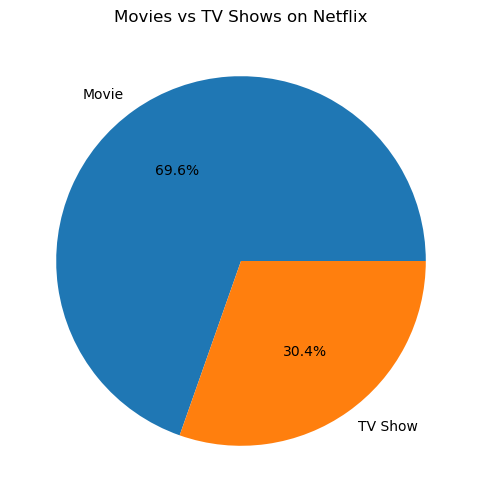

In [10]:
#Trend Identification - Movies vs TV Shows
type_count = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_count,
        labels=type_count.index,
        autopct='%1.1f%%')

plt.title("Movies vs TV Shows on Netflix")

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\movies_vs_tvshows.png")
plt.show()

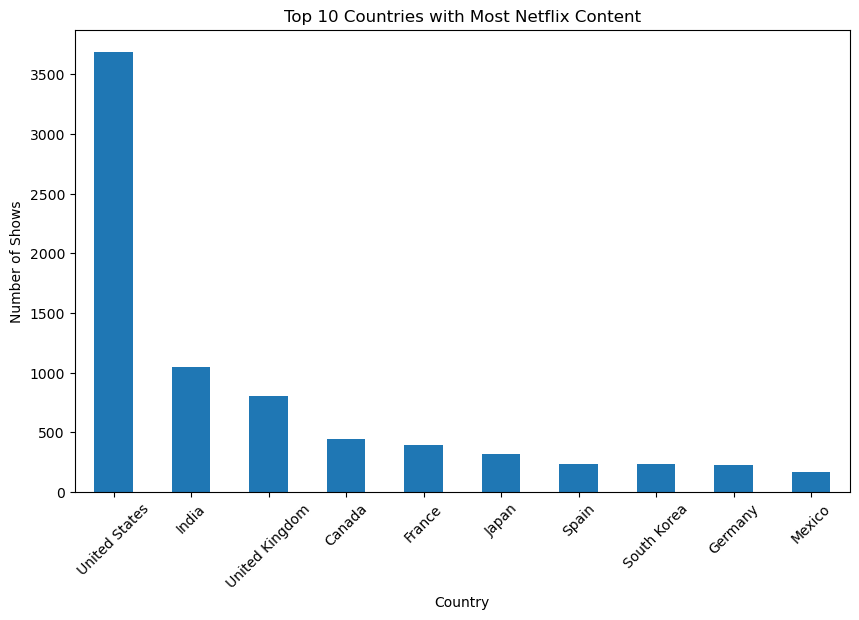

In [11]:
#Trend Identification - Top 10 Countries Producing Content
country_count = df['country'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,6))
country_count.plot(kind='bar')

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")

plt.xticks(rotation=45)

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\top_countries.png")
plt.show()

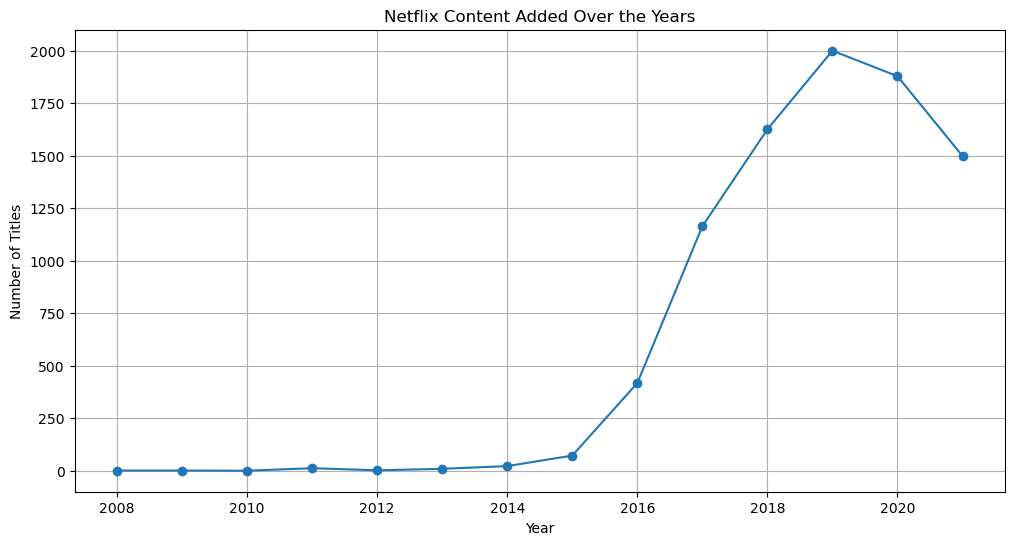

In [12]:
#Trend Identification - Content Added Over the Years
year_added = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(year_added.index,
         year_added.values,
         marker='o')

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\content_added_yearwise.png")
plt.show()

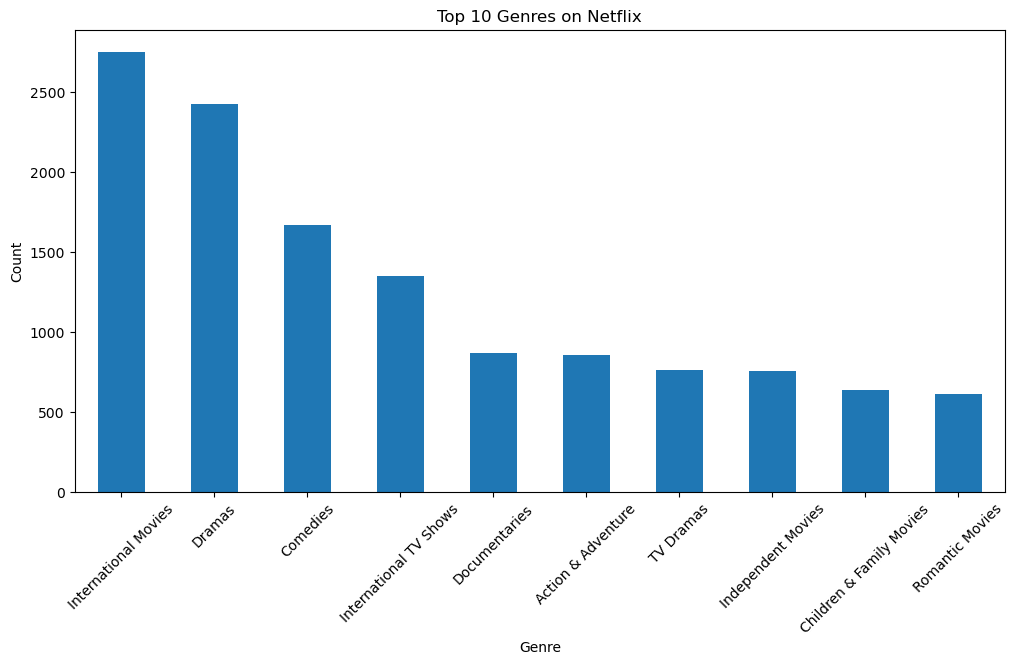

In [13]:
# TOP 10 GENRES
genre_count = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(12,6))
genre_count.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\top_genres.png")
plt.show()


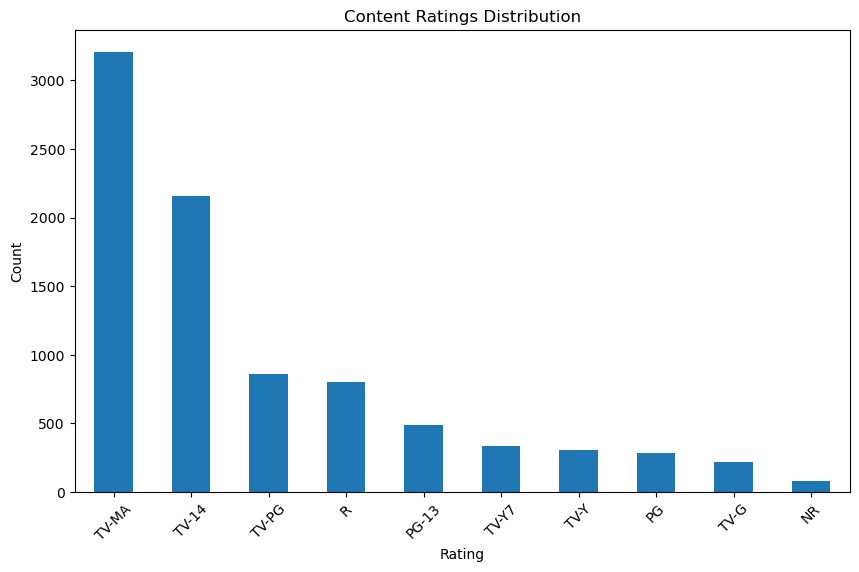

In [14]:
# RATINGS DISTRIBUTION
rating_count = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))
rating_count.plot(kind='bar')

plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\ratings_distribution.png")
plt.show()


Correlation Matrix:
              release_year  year_added
release_year      1.000000    0.110473
year_added        0.110473    1.000000


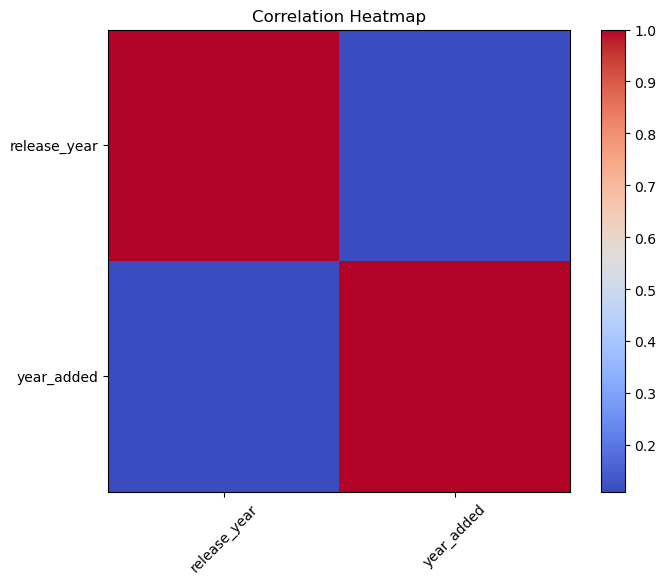

In [15]:
# CORRELATION ANALYSIS
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation Matrix
correlation = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation)

# Plot Correlation Heatmap
plt.figure(figsize=(8,6))

plt.imshow(correlation,
           cmap='coolwarm',
           interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task3\correlation_heatmap.png")
plt.show()
